In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

In [ ]:
conn=sqlite3.connect("../Dataset/inventory.db")
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print("Table name=",table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

Table name= purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name= purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name= vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name= begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name= end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
vendor_df=pd.read_sql_query(f"select * from vendor_invoice",conn)

In [6]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


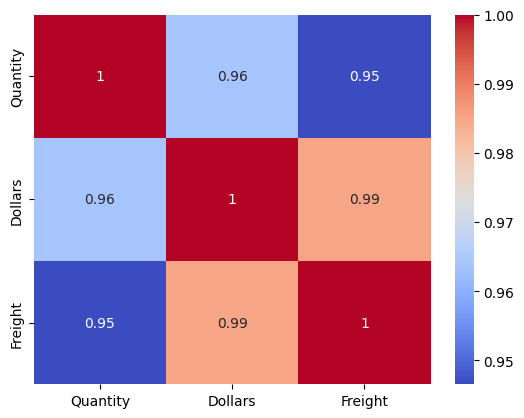

In [7]:
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot=True,cmap='coolwarm')
plt.show()

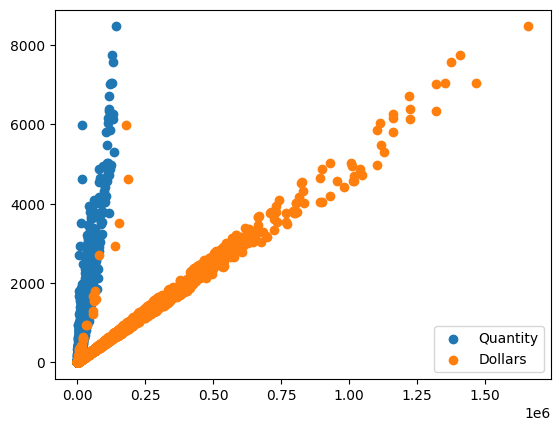

In [8]:
plt.scatter(vendor_df['Quantity'],vendor_df['Freight'])
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'])
plt.legend(["Quantity","Dollars"])
plt.show()

In [9]:
vendor_df['Freight_per_unit']=vendor_df['Freight']/vendor_df["Quantity"]

In [10]:
vendor_df.head(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809


In [18]:
vendor_df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight,Freight_per_unit
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301,0.068242
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093,0.084333
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000,0.005367
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000,0.038561
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000,0.050824
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000,0.074710
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000,3.106000


In [141]:
X=vendor_df[['Dollars']]
Y=vendor_df['Freight']

In [143]:
from sklearn.model_selection import train_test_split

In [144]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=0.2,random_state=42)

In [145]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [146]:
lnr=LinearRegression()
d_tree=DecisionTreeRegressor(max_depth=3)
rf=RandomForestRegressor(max_depth=3)

In [147]:
lnr.fit(x_train,y_train)
d_tree.fit(x_train,y_train)
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [148]:
def evaluate_model(model,x_test,y_test,model_name):
    pred=model.predict(x_test)
    mae=mean_absolute_error(pred,y_test)
    mse=mean_squared_error(pred,y_test)
    r2=r2_score(y_test,pred)*100

    print(f"\n{model_name} peraformance:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R2: {r2:.2f}%")

In [149]:
evaluate_model(lnr,x_test,y_test,"Linear Regression")


Linear Regression peraformance:
MAE: 23.38
MSE: 16834.89
R2: 96.64%


In [150]:
evaluate_model(d_tree,x_test,y_test,"Decision Tree")


Decision Tree peraformance:
MAE: 70.31
MSE: 28924.26
R2: 94.23%


In [151]:
evaluate_model(rf,x_test,y_test,"Random Forest")


Random Forest peraformance:
MAE: 54.08
MSE: 22024.71
R2: 95.61%


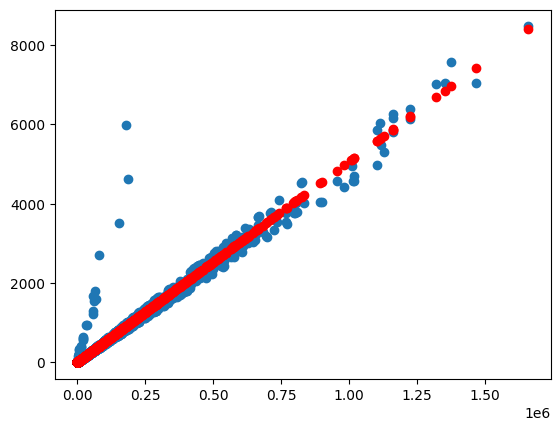

In [156]:
plt.scatter(x_test,y_test)
plt.scatter(x_test,lnr.predict(x_test),color='red')
plt.show()

In [161]:
input_data={
    "Dollars":[4000,40000,18500],
}
df1=pd.DataFrame(input_data)

In [162]:
lnr.predict(df1)

array([ 21.57611458, 203.45863133,  94.83435049])